# News Category Automation NLP

# EDA

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
data = pd.read_csv('../data/processed/news_data_processed.csv')

In [3]:
data.head()

,link,category,authors,date,description,language
0,https://www.huffpost.com/entry/covid-boosters-...,News,"Carla K. Johnson, AP",2022-09-23,"['million', 'american', 'roll', 'sleeve', 'omi...",en
1,https://www.huffpost.com/entry/american-airlin...,News,Mary Papenfuss,2022-09-23,"['american', 'airline', 'flyer', 'charged', 'b...",en
2,https://www.huffpost.com/entry/funniest-tweets...,Entertainment,Elyse Wanshel,2022-09-23,"['funniest', 'tweet', 'cat', 'dog', 'week', 's...",en
3,https://www.huffpost.com/entry/funniest-parent...,Lifestyle,Caroline Bologna,2022-09-23,"['funniest', 'tweet', 'parent', 'week', 'sept'...",en
4,https://www.huffpost.com/entry/amy-cooper-lose...,News,Nina Golgowski,2022-09-22,"['woman', 'called', 'cop', 'black', 'birdwatch...",en


In [4]:
# Drop language column
data.drop('language', axis=1, inplace=True)

# Category Breakdown

In [5]:
# Get value count by category
data['category'].value_counts()

category
Lifestyle                51430
News                     48207
Health                   31476
Entertainment            21820
Arts & Culture           15947
Science & Environment     8376
Business                  8133
Sports                    4414
Name: count, dtype: int64

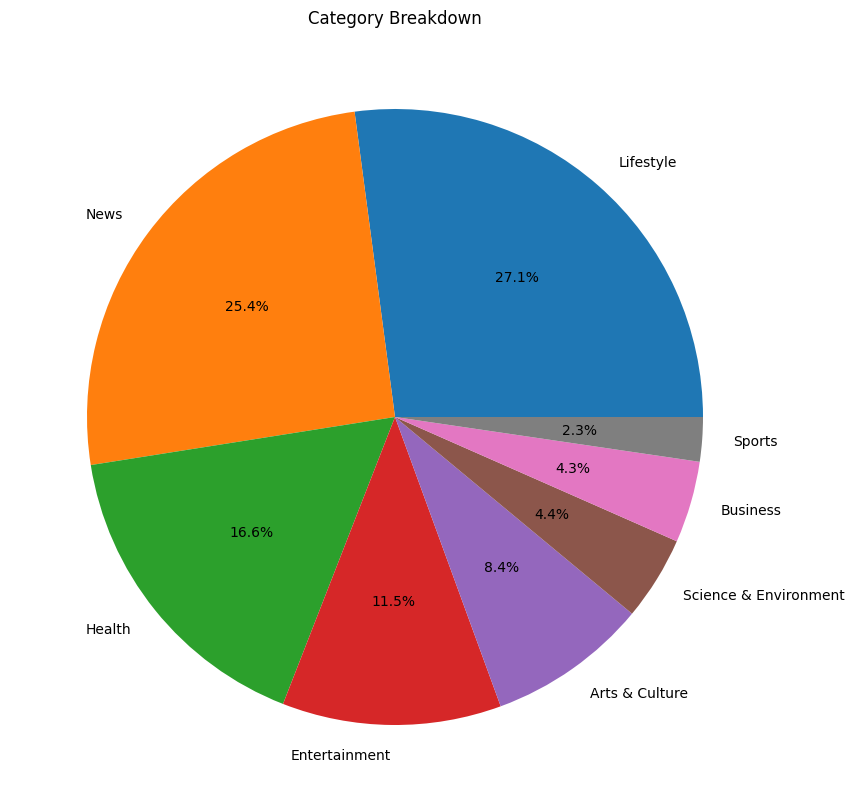

In [6]:
# Pie chart for categories
plt.figure(figsize=(12,10))
plt.pie(data['category'].value_counts(), labels=data['category'].value_counts().index, autopct='%1.1f%%')
plt.title('Category Breakdown')
plt.show()

Here we can see that Lifestyle and News share over half of our total results. Health and Entertainment also have more than a 10% share while all other categories are under that mark.

# Word/Character Counts

Here we'll examine the length of each description and save that as a column for our df

In [7]:
# Create character count column
data['char_count'] = data['description'].apply(len)
data.head()

,link,category,authors,date,description,char_count
0,https://www.huffpost.com/entry/covid-boosters-...,News,"Carla K. Johnson, AP",2022-09-23,"['million', 'american', 'roll', 'sleeve', 'omi...",229
1,https://www.huffpost.com/entry/american-airlin...,News,Mary Papenfuss,2022-09-23,"['american', 'airline', 'flyer', 'charged', 'b...",235
2,https://www.huffpost.com/entry/funniest-tweets...,Entertainment,Elyse Wanshel,2022-09-23,"['funniest', 'tweet', 'cat', 'dog', 'week', 's...",106
3,https://www.huffpost.com/entry/funniest-parent...,Lifestyle,Caroline Bologna,2022-09-23,"['funniest', 'tweet', 'parent', 'week', 'sept'...",221
4,https://www.huffpost.com/entry/amy-cooper-lose...,News,Nina Golgowski,2022-09-22,"['woman', 'called', 'cop', 'black', 'birdwatch...",261


In [8]:
# Create word count column
data['word_count'] = data['description'].apply(lambda x: len(x.split()))
data.head()

,link,category,authors,date,description,char_count,word_count
0,https://www.huffpost.com/entry/covid-boosters-...,News,"Carla K. Johnson, AP",2022-09-23,"['million', 'american', 'roll', 'sleeve', 'omi...",229,23
1,https://www.huffpost.com/entry/american-airlin...,News,Mary Papenfuss,2022-09-23,"['american', 'airline', 'flyer', 'charged', 'b...",235,22
2,https://www.huffpost.com/entry/funniest-tweets...,Entertainment,Elyse Wanshel,2022-09-23,"['funniest', 'tweet', 'cat', 'dog', 'week', 's...",106,12
3,https://www.huffpost.com/entry/funniest-parent...,Lifestyle,Caroline Bologna,2022-09-23,"['funniest', 'tweet', 'parent', 'week', 'sept'...",221,21
4,https://www.huffpost.com/entry/amy-cooper-lose...,News,Nina Golgowski,2022-09-22,"['woman', 'called', 'cop', 'black', 'birdwatch...",261,25


In [9]:
# Create word length column
data['word_length'] = data['description'].apply(lambda x: np.mean([len(word) for word in x.split()]))
data.head()

,link,category,authors,date,description,char_count,word_count,word_length
0,https://www.huffpost.com/entry/covid-boosters-...,News,"Carla K. Johnson, AP",2022-09-23,"['million', 'american', 'roll', 'sleeve', 'omi...",229,23,9.000000
1,https://www.huffpost.com/entry/american-airlin...,News,Mary Papenfuss,2022-09-23,"['american', 'airline', 'flyer', 'charged', 'b...",235,22,9.727273
2,https://www.huffpost.com/entry/funniest-tweets...,Entertainment,Elyse Wanshel,2022-09-23,"['funniest', 'tweet', 'cat', 'dog', 'week', 's...",106,12,7.916667
3,https://www.huffpost.com/entry/funniest-parent...,Lifestyle,Caroline Bologna,2022-09-23,"['funniest', 'tweet', 'parent', 'week', 'sept'...",221,21,9.571429
4,https://www.huffpost.com/entry/amy-cooper-lose...,News,Nina Golgowski,2022-09-22,"['woman', 'called', 'cop', 'black', 'birdwatch...",261,25,9.480000


In [10]:
# Examine count/length categories
data.describe()

,char_count,word_count,word_length
count,189803.000000,189803.000000,189803.000000
mean,185.764487,18.510345,9.088044
std,67.908290,6.595956,0.685868
min,17.000000,2.000000,6.444444
25%,141.000000,14.000000,8.615385
50%,180.000000,18.000000,9.052632
75%,219.000000,22.000000,9.523810
max,1425.000000,139.000000,17.888889


We can see here that the max results for character count and word count may be outliers. They are far more than even 3 standard deviations from the mean. We'll have to examine this.

Word length has a pretty small window around 8 so we probably won't be able to get too much value from this.

In [11]:
# Create function for box plot to examine outliers
def box_plot(column):
    plt.figure(figsize=(12,10))
    sns.boxplot(y=column, data=data)

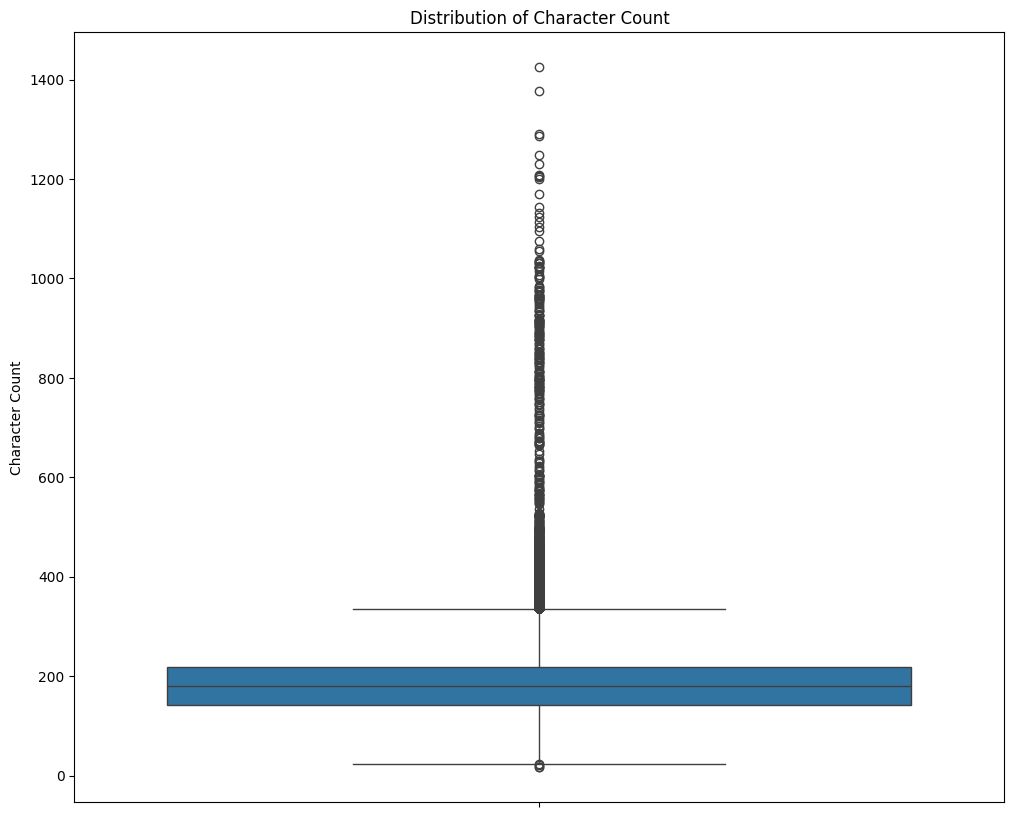

In [12]:
# Box plot of character count
box_plot('char_count')
plt.ylabel('Character Count')
plt.title('Distribution of Character Count')
plt.show()

There are a good amount of values under around 1000 characters. We can look at the values over 1000 to see if there are any abnormalities there.

In [13]:
# Examine descriptions with character counts over 1000
lg_char_count = data[data['char_count'] > 1000]

# Set option to display full column
pd.set_option('display.max_colwidth', None)

lg_char_count


,link,category,authors,date,description,char_count,word_count,word_length
60624,https://www.huffingtonpost.com/entry/sunday-roundup_457_b_11157160.html,News,"Arianna Huffington, Contributor",2016-07-24,"['sunday', 'roundup', 'week', 'nation', 'came', 'one', 'step', 'closer', 'giving', 'dangerous', 'unstable', 'potential', 'leader', 'history', 'donald', 'trump', 'humbly', 'accepted', 'republican', 'presidential', 'nomination', 'humbly', 'fact', 'went', 'claim', 'alone', 'fix', 'america', 'capped', 'week', 'nightly', 'disarray', 'trump', 'living', 'chaos', 'candidate', 'title', 'given', 'jeb', 'bush', 'shone', 'endless', 'largely', 'shouted', 'speech', 'fear', 'fear', 'immigrant', 'fear', 'diversity', 'fear', 'nation', 'america', 'become', 'key', 'refrain', 'trump', 'promising', 'make', 'america', 'strong', 'proud', 'safe', 'never', 'mind', 'america', 'actually', 'instance', 'safe', 'despite', 'recent', 'uptick', 'crime', 'still', 'historic', 'low', 'trump', 'builder', 'building', 'sinister', 'vision', 'lost', 'eden', 'one', 'thats', 'taken', 'away', 'scary', 'dangerous', 'call', 'unity', 'unity', 'removal', 'trump', 'rebranded', 'america', 'dark', 'hostile', 'pessimistic', 'fearful', 'place', 'win', 'building', 'place', 'mind', 'paraphrase', 'fdr', 'nothing', 'fear', 'manipulation', 'cynical', 'nurturing', 'fear', 'trump', 'essence', 'shorting', 'america', 'thats', 'bet', 'thats', 'bet', 'must', 'reject', 'poll', 'mind', 'heart']",1249,126,8.920635
61238,https://www.huffingtonpost.com/entry/sunday-roundup_456_b_11033924.html,News,"Arianna Huffington, Contributor",2016-07-17,"['sunday', 'roundup', 'week', 'tragedy', 'chaos', 'world', 'looking', 'horror', 'truckdriving', 'terrorist', 'plowed', 'crowd', 'celebrating', 'bastille', 'day', 'nice', 'killing', 'people', 'injuring', '200', 'next', 'evening', 'faction', 'turkish', 'military', 'attempted', 'coup', 'president', 'erdogan', 'meanwhile', 'donald', 'trump', 'postponed', 'friday', 'announcement', 'running', 'mate', 'mike', 'penny', 'according', 'campaign', 'manager', 'paul', 'manafort', 'trump', 'reacted', 'emotionally', 'nice', 'attack', 'also', 'report', 'late', 'thursday', 'night', 'trump', 'making', 'call', 'see', 'could', 'reverse', 'choice', 'penny', 'man', 'wrote', 'global', 'warming', 'myth', 'smoking', 'doesnt', 'kill', 'apparently', 'doesnt', 'believe', 'evolution', 'uncertain', 'unsteady', 'time', 'call', 'steady', 'cleareyed', 'leadership', 'emotionally', 'driven', 'hoc', 'improvising', 'posturing', 'eve', 'republican', 'convention', 'dont', 'need', 'know', 'whether', 'tim', 'tebow', 'end', 'speaking', 'know', 'donald', 'trump', 'dangerously', 'unfit', 'lead', 'country', 'lead', 'world']",1095,106,9.339623
62413,https://www.huffingtonpost.com/entry/sunday-roundup_455_b_10787940.html,News,"Arianna Huffington, Contributor",2016-07-03,"['sunday', 'roundup', 'week', 'nation', 'reminded', 'way', 'good', 'bad', 'election', 'matter', 'monday', 'supreme', 'court', 'likely', 'see', 'multiple', 'appointment', 'next', 'president', 'delivered', 'landmark', 'decision', 'reproductive', 'right', 'tuesday', 'terrorist', 'bombed', 'istanbul', 'airport', 'leaving', 'dead', 'right', 'cue', 'donald', 'trump', 'reminded', 'world', 'judgment', 'stability', 'matter', 'repeating', 'call', 'torture', 'saying', 'fight', 'fire', 'fire', 'fallout', 'brexit', 'continues', 'republican', 'official', 'beating', 'drum', 'trexit', 'separating', 'toxic', 'menace', 'trump', 'utah', 'senator', 'mike', 'lee', 'said', 'wont', 'vote', 'trump', 'without', 'assurance', 'wont', 'abuse', 'constitution', 'maine', 'senator', 'susan', 'collins', 'hinted', 'might', 'vote', 'hillary', 'clinton', 'mitt', 'romney', 'said', 'hed', 'vote', 'wife', 'trump', 'meanwhile', 'illinois', 'senator', 'mark', 'kirk', 'became', 'first', 'gop', 'incumbent', 'air', 'antitrump', 'list', 'trexiting', 'elected', 'official', 'grows', 'nevertrump', 'rnc', 'effort', 'insert', 'conscience', 'clause', 'allowing', 'delegate', 'vote', 'cand

It seems that mose of these are weekend or week round ups where they are touching on a lot of info/topics. When exploring the links these all look like valid descriptions.

Now we'll examine word count in a similar way.

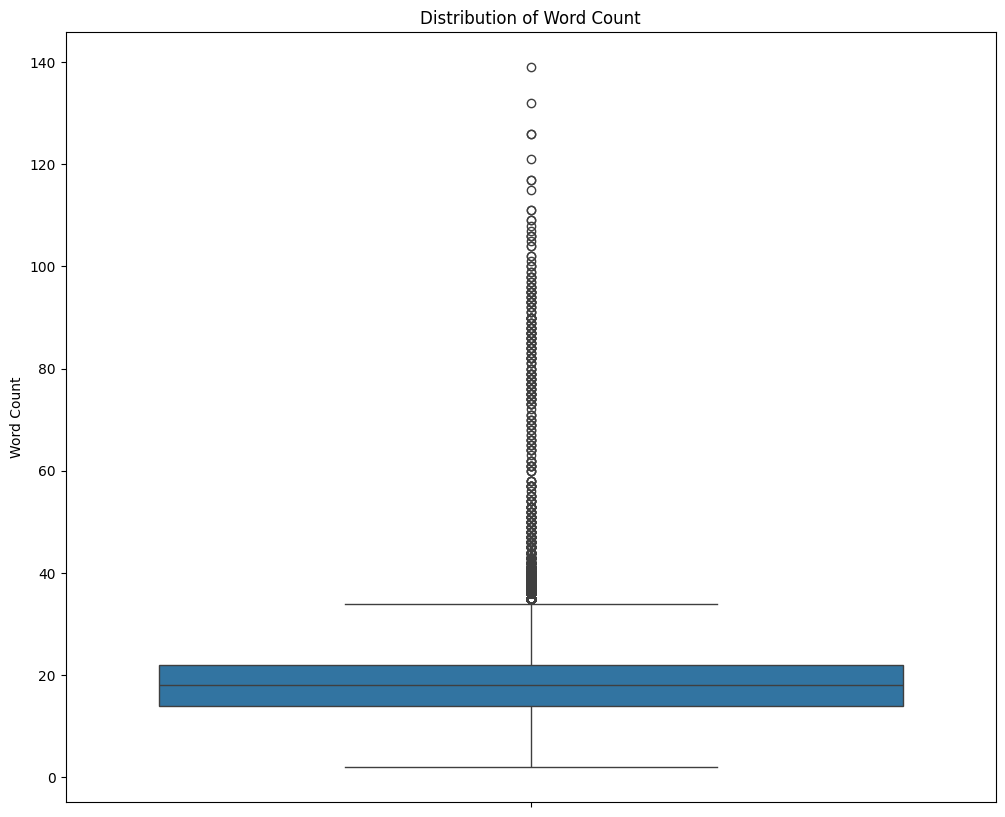

In [14]:
# Box plot of word count
box_plot('word_count')
plt.ylabel('Word Count')
plt.title('Distribution of Word Count')
plt.show()

Here the data seems to get more sparse around the 115 word count range. We'll examine those values

In [15]:
# Subset of rows with > 115 words
lg_word_count = data[data['word_count'] > 115]

lg_word_count

,link,category,authors,date,description,char_count,word_count,word_length
60624,https://www.huffingtonpost.com/entry/sunday-roundup_457_b_11157160.html,News,"Arianna Huffington, Contributor",2016-07-24,"['sunday', 'roundup', 'week', 'nation', 'came', 'one', 'step', 'closer', 'giving', 'dangerous', 'unstable', 'potential', 'leader', 'history', 'donald', 'trump', 'humbly', 'accepted', 'republican', 'presidential', 'nomination', 'humbly', 'fact', 'went', 'claim', 'alone', 'fix', 'america', 'capped', 'week', 'nightly', 'disarray', 'trump', 'living', 'chaos', 'candidate', 'title', 'given', 'jeb', 'bush', 'shone', 'endless', 'largely', 'shouted', 'speech', 'fear', 'fear', 'immigrant', 'fear', 'diversity', 'fear', 'nation', 'america', 'become', 'key', 'refrain', 'trump', 'promising', 'make', 'america', 'strong', 'proud', 'safe', 'never', 'mind', 'america', 'actually', 'instance', 'safe', 'despite', 'recent', 'uptick', 'crime', 'still', 'historic', 'low', 'trump', 'builder', 'building', 'sinister', 'vision', 'lost', 'eden', 'one', 'thats', 'taken', 'away', 'scary', 'dangerous', 'call', 'unity', 'unity', 'removal', 'trump', 'rebranded', 'america', 'dark', 'hostile', 'pessimistic', 'fearful', 'place', 'win', 'building', 'place', 'mind', 'paraphrase', 'fdr', 'nothing', 'fear', 'manipulation', 'cynical', 'nurturing', 'fear', 'trump', 'essence', 'shorting', 'america', 'thats', 'bet', 'thats', 'bet', 'must', 'reject', 'poll', 'mind', 'heart']",1249,126,8.920635
62413,https://www.huffingtonpost.com/entry/sunday-roundup_455_b_10787940.html,News,"Arianna Huffington, Contributor",2016-07-03,"['sunday', 'roundup', 'week', 'nation', 'reminded', 'way', 'good', 'bad', 'election', 'matter', 'monday', 'supreme', 'court', 'likely', 'see', 'multiple', 'appointment', 'next', 'president', 'delivered', 'landmark', 'decision', 'reproductive', 'right', 'tuesday', 'terrorist', 'bombed', 'istanbul', 'airport', 'leaving', 'dead', 'right', 'cue', 'donald', 'trump', 'reminded', 'world', 'judgment', 'stability', 'matter', 'repeating', 'call', 'torture', 'saying', 'fight', 'fire', 'fire', 'fallout', 'brexit', 'continues', 'republican', 'official', 'beating', 'drum', 'trexit', 'separating', 'toxic', 'menace', 'trump', 'utah', 'senator', 'mike', 'lee', 'said', 'wont', 'vote', 'trump', 'without', 'assurance', 'wont', 'abuse', 'constitution', 'maine', 'senator', 'susan', 'collins', 'hinted', 'might', 'vote', 'hillary', 'clinton', 'mitt', 'romney', 'said', 'hed', 'vote', 'wife', 'trump', 'meanwhile', 'illinois', 'senator', 'mark', 'kirk', 'became', 'first', 'gop', 'incumbent', 'air', 'antitrump', 'list', 'trexiting', 'elected', 'official', 'grows', 'nevertrump', 'rnc', 'effort', 'insert', 'conscience', 'clause', 'allowing', 'delegate', 'vote', 'candidate', 'violates', 'moral', 'belief', 'convention', 'nears', 'finding', 'whose', 'conscience', 'put', 'country', 'party', 'whose']",1286,126,9.214286
65977,https://www.huffingtonpost.com/entry/sunday-roundup_449_b_10085936.html,News,"Arianna Huffington, Contributor",2016-05-22,"['sunday', 'roundup', 'week', 'nation', 'watched', 'nevertrump', 'movement', 'folded', 'faster', 'one', 'presumptive', 'nominee', 'beachfront', 'development', 'many', 'tried', 'explain', 'away', 'trump', 'reckless', 'racist', 'extremism', 'put', 'principle', 'party', 'wife', 'former', 'republican', 'senator', 'bob', 'bennett', 'died', 'may', 'revealed', 'husband', 'spent', 'dying', 'hour', 'reaching', 'muslim', 'would', 'people', 'hijab', 'tell', 'glad', 'america', 'told', 'daily', 'beast', 'wanted', 'apologize', 'behalf', 'republican', 'party', 'prime', 'minister', 'david', 'cameron', 'called', 'trump', 'proposal', 'ban', 'muslim', 'entering', 'divisive', 'stupid', 'wrong', 'trump', 'reply', 'didnt', 'think', 'cameron', 'would', 'good', 'relationship', 'press', 'also', 'part', 'whitewash', 'extremism', 'new', 'york', 'time', 'called', 'trump', 'racism', 'reductive', 'approach', 'ethnicity', 'said', 'trump', 'attitude', 'toward', 'woman', 'complex', 

These are all in the columns that were in our large character count subset (as could be expected). I inspected these before and they all seem legitimate so we don't need to do anything about these.

## Counts by Category

Now that we created the necessary columns, I'll examine these counts by category. First we'll look at character count by category

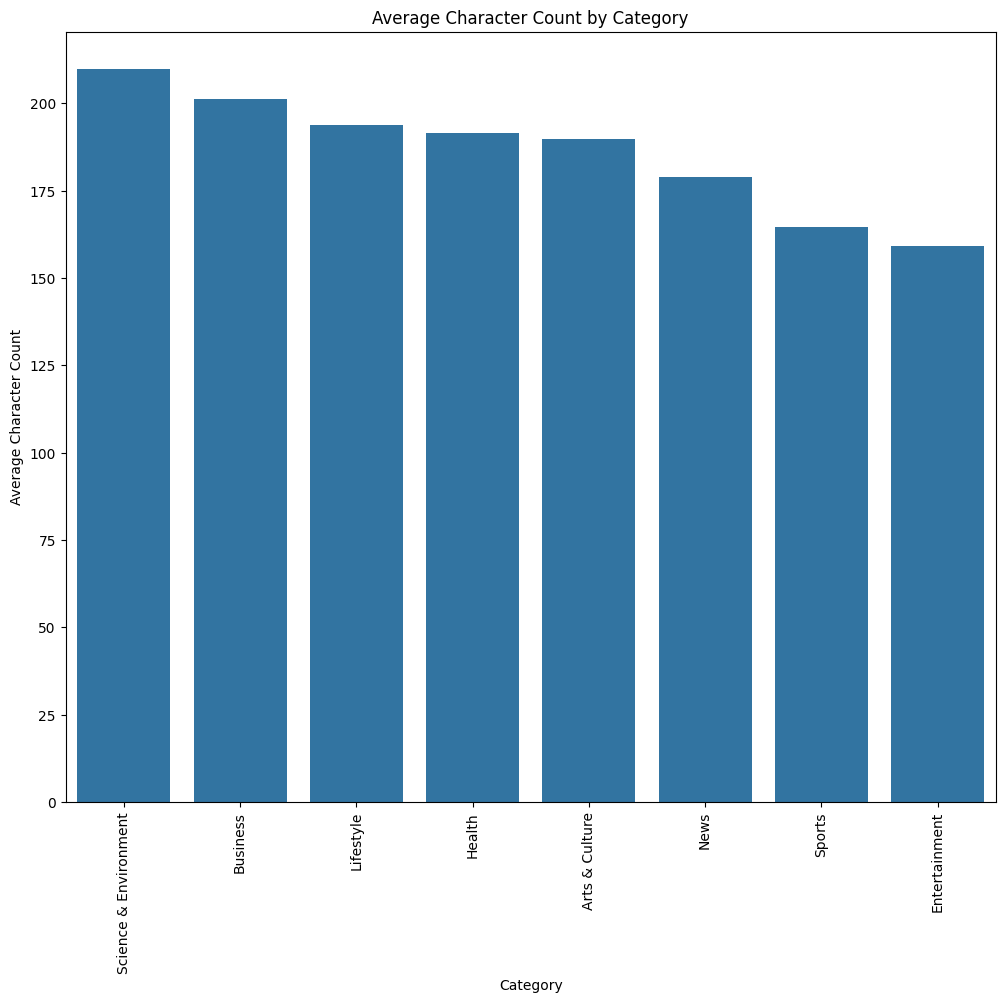

In [16]:
# Average character count by category
char_mean = data.groupby('category')['char_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,10))
sns.barplot(x=char_mean.index, y=char_mean.values)
plt.xlabel('Category')
plt.ylabel('Average Character Count')
plt.xticks(rotation=90)
plt.title('Average Character Count by Category')
plt.show()

In [17]:
char_mean

category
Science & Environment    209.974331
Business                 201.193164
Lifestyle                193.886350
Health                   191.623269
Arts & Culture           189.779959
News                     179.071110
Sports                   164.491391
Entertainment            159.281943
Name: char_count, dtype: float64

The categories all fall within 159-210 characters. Science and environment leads in mean character count. Sports and entertainment are the lowest around the 160 mark.

Now we'll look at the same visualizations for word count

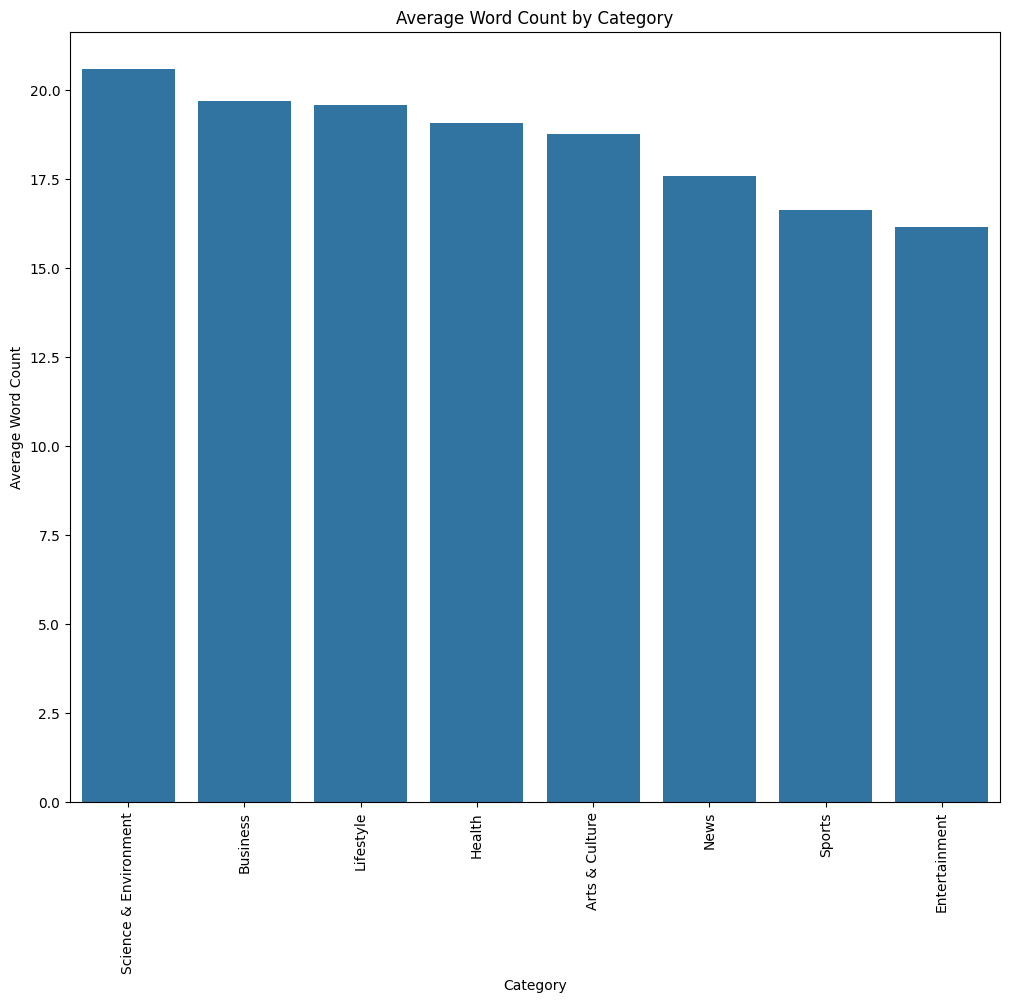

In [18]:
# Average word count by category
word_mean = data.groupby('category')['word_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,10))
sns.barplot(x=word_mean.index, y=word_mean.values)
plt.xlabel('Category')
plt.ylabel('Average Word Count')
plt.xticks(rotation=90)
plt.title('Average Word Count by Category')
plt.show()

In [19]:
word_mean

category
Science & Environment    20.610315
Business                 19.689414
Lifestyle                19.574742
Health                   19.089687
Arts & Culture           18.770803
News                     17.585434
Sports                   16.644993
Entertainment            16.150642
Name: word_count, dtype: float64

We can see the categories fall between 15-20 words per description with Science and Business leading the way and Lifestyle in a similar place.. More light topics crowd the bottom of this like Sports and Entertainment.


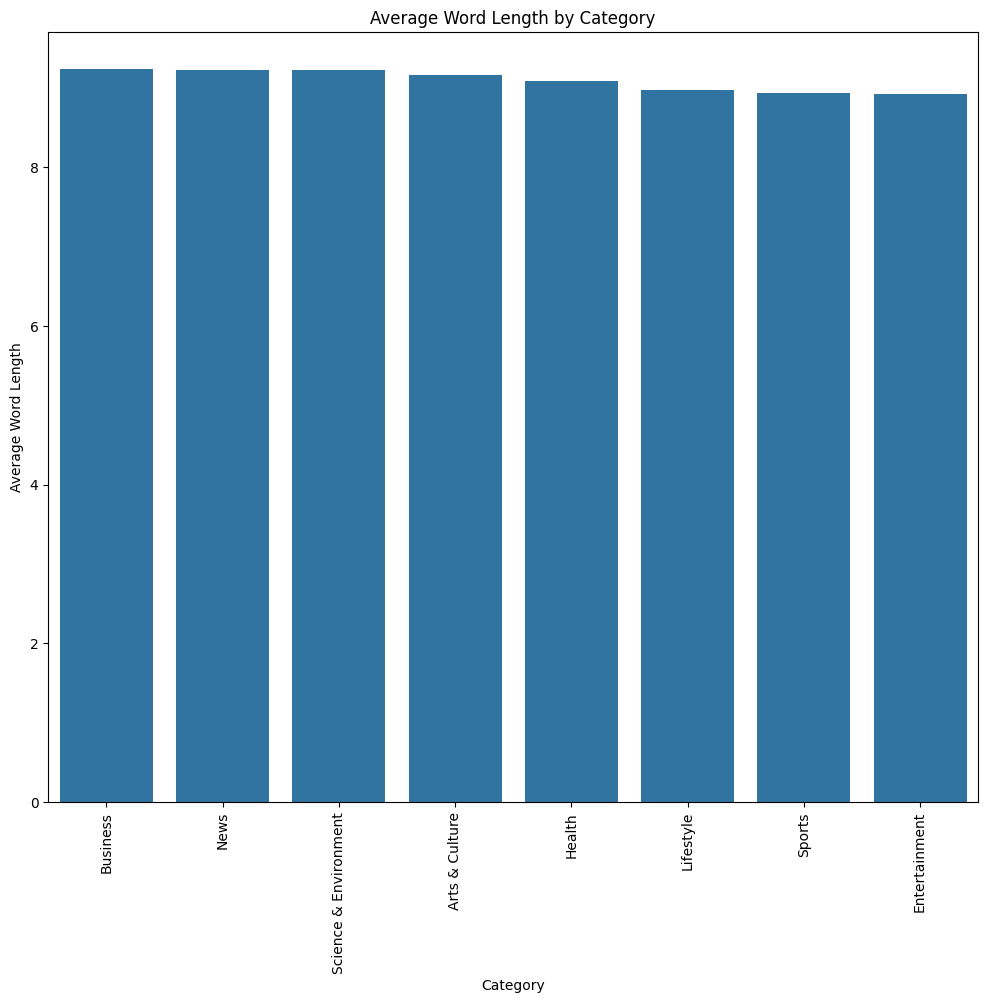

In [20]:
# Plot word length by category
word_length_mean = data.groupby('category')['word_length'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,10))
sns.barplot(x=word_length_mean.index, y=word_length_mean.values)
plt.xlabel('Category')
plt.ylabel('Average Word Length')
plt.xticks(rotation=90)
plt.title('Average Word Length by Category')
plt.show()

In [21]:
word_length_mean

category
Business                 9.240959
News                     9.227175
Science & Environment    9.226297
Arts & Culture           9.164244
Health                   9.088919
Lifestyle                8.969338
Sports                   8.938970
Entertainment            8.923587
Name: word_length, dtype: float64

These seem pretty similar across the board showing no real correlation as they are all within 0.2 letter length per word.

# Term Frequncy Analysis

Here we will look at what words are occuring the most in our descriptions.

In [22]:
# Find most frequently occuring words
most_freq = pd.Series(' '.join(data['description']).split()).value_counts()[:25]
most_freq

'new',       16738
'trump',     16368
'one',       15233
'photo',     13607
'day',       12145
'eye',       11962
'year',      11887
'people',    11490
'say',       11260
'Tears',     11157
'like',      11063
'make',      10628
'get',       10558
'life',       9848
'way',        8429
'want',       8257
'woman',      8007
'first',      7566
'know',       7563
'world',      7458
'video',      7328
'week',       7200
'need',       7173
'may',        7004
'take',       6940
Name: count, dtype: int64

We can see here that 'new' is the top occuring word in our data set, probably also stemming from 'news'. 'trump' is the second highest occuring which makes sense as politics was the biggest category and the data spans from 2012-2022 where Trump was in the news cycle very frequently.

I'll plot this data to depict this visually

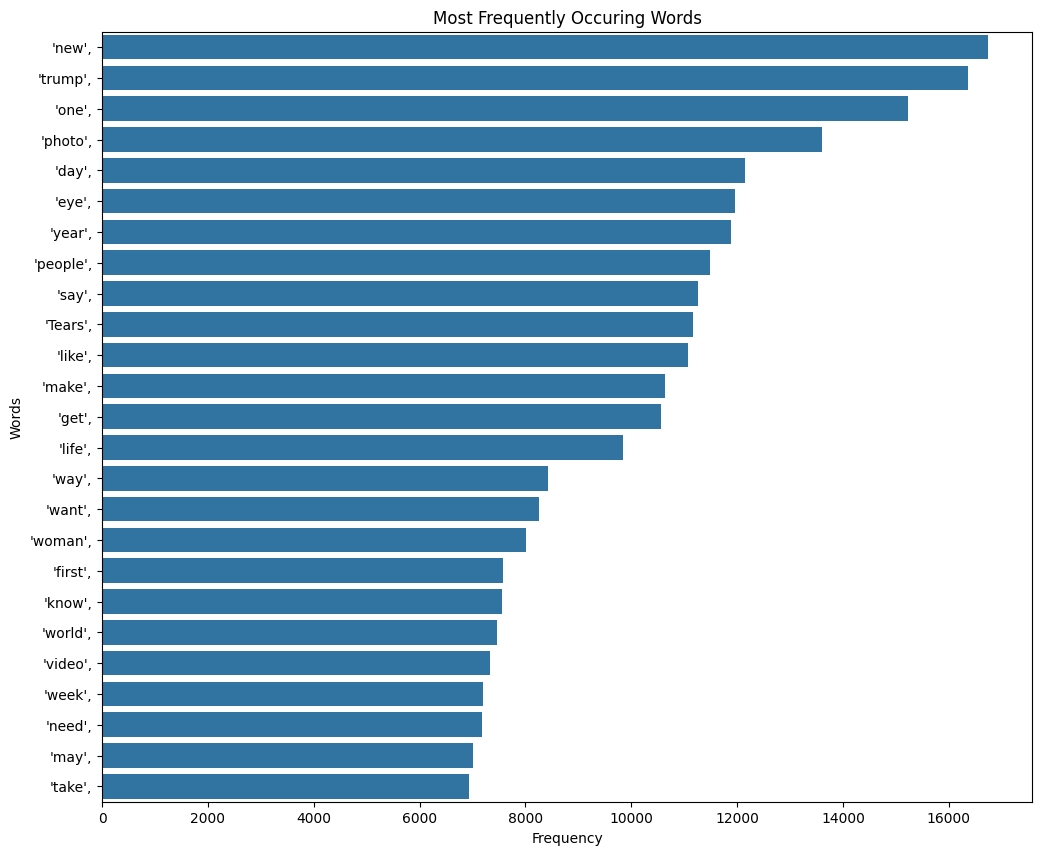

In [23]:
# Create words and frequency subsets to plot data
words = most_freq.index
freq = most_freq.values

# Plot data
plt.figure(figsize=(12,10))
sns.barplot(x=freq, y=words)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Most Frequently Occuring Words')
plt.show()

Now we'll examine the most frequent words by category

In [24]:
# Create set of most frequent words by category
cat_most_freq = data.groupby('category')['description'].apply(lambda x: pd.Series(' '.join(x).split()).value_counts()[:1])
cat_most_freq.head(10)

category                       
Arts & Culture         'gay',       1717
Business               'new',        974
Entertainment          'trump',     2786
Health                 'life',      3696
Lifestyle              'photo',    10404
News                   'trump',    12091
Science & Environment  'new',        847
Sports                 'game',       513
Name: description, dtype: int64

Let's plot this to see it visually

In [25]:
# Separate word from index
cat_most_freq = cat_most_freq.reset_index()
cat_most_freq.head()

,category,level_1,description
0,Arts & Culture,"'gay',",1717
1,Business,"'new',",974
2,Entertainment,"'trump',",2786
3,Health,"'life',",3696
4,Lifestyle,"'photo',",10404


In [26]:
# Rename word/count columns
cat_most_freq.rename(columns={'level_1': 'word'}, inplace=True)
cat_most_freq.rename(columns={'description': 'count'}, inplace=True)
cat_most_freq.head()

,category,word,count
0,Arts & Culture,"'gay',",1717
1,Business,"'new',",974
2,Entertainment,"'trump',",2786
3,Health,"'life',",3696
4,Lifestyle,"'photo',",10404


We'll sort the values for better visual appeal

In [27]:
# Sort by frequency
cat_most_freq = cat_most_freq.sort_values(by='count', ascending=False)

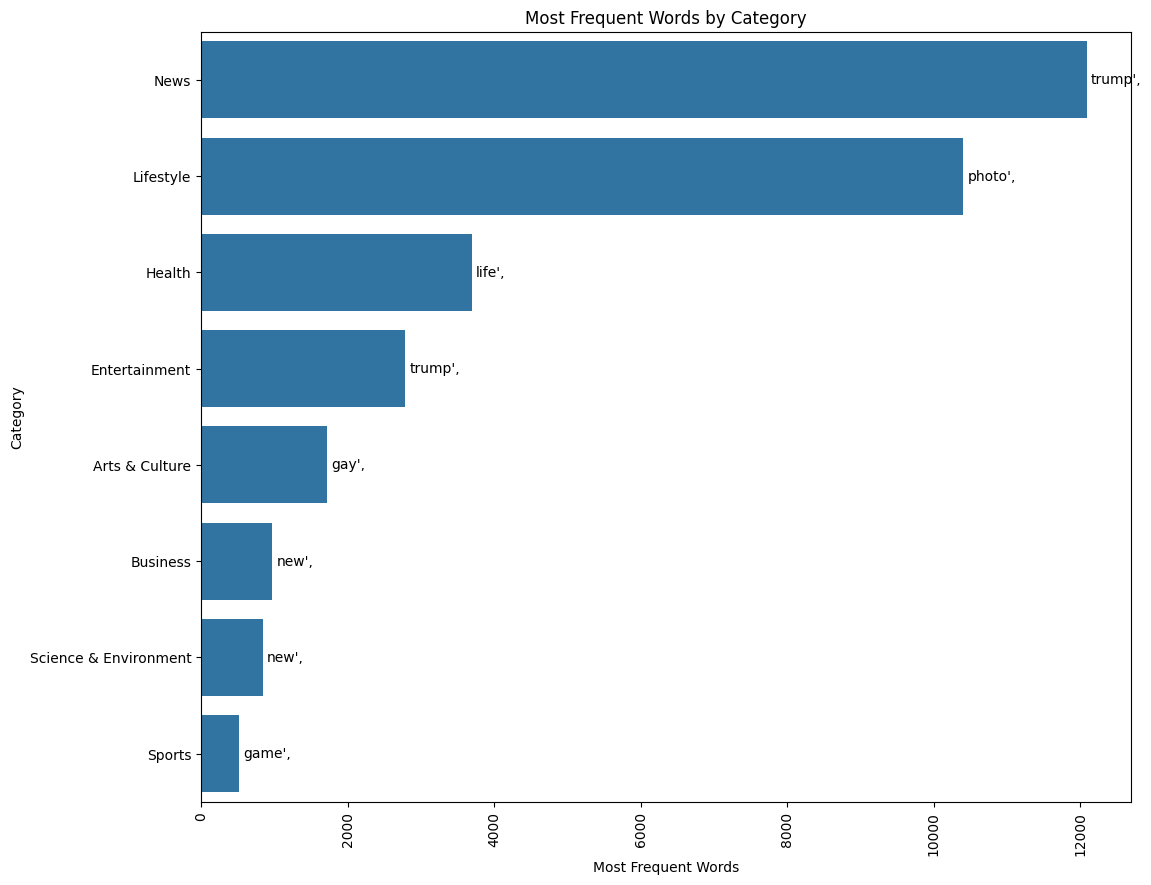

In [28]:
# Plot category most freq words
fig, ax = plt.subplots(figsize=(12,10))
sns.barplot(x='count', y='category', data=cat_most_freq)
# Extract the word from the string representation of the list
ax.bar_label(ax.containers[0], labels=[word.strip("['']") for word in cat_most_freq.word], padding=3)
plt.xlabel('Most Frequent Words')
plt.ylabel('Category')
plt.xticks(rotation=90)
plt.title('Most Frequent Words by Category')
plt.show()

We can see that 'trump' is very frequently occuring in the news category,  appearing about 12000 times. Trump also leads in entertainment. New also had 2 categories where it was the most frequent word in Science and Business.

We can also look at the percentage of total word count each word is taking up to give us a better sense of how frequent each category is using each word

In [29]:
# Get sum of word count for each category
word_count_sum = data.groupby('category')['word_count'].sum()
word_count_sum

category
Arts & Culture            299338
Business                  160134
Entertainment             352407
Health                    600867
Lifestyle                1006729
News                      847741
Science & Environment     172632
Sports                     73471
Name: word_count, dtype: int64

In [30]:
# Join with most_freq df and get percentage
cat_most_freq = cat_most_freq.merge(word_count_sum, on='category')
cat_most_freq['percentage'] = (cat_most_freq['count'] / cat_most_freq['word_count'] * 100).round(2)
cat_most_freq

,category,word,count,word_count,percentage
0,News,"'trump',",12091,847741,1.43
1,Lifestyle,"'photo',",10404,1006729,1.03
2,Health,"'life',",3696,600867,0.62
3,Entertainment,"'trump',",2786,352407,0.79
4,Arts & Culture,"'gay',",1717,299338,0.57
5,Business,"'new',",974,160134,0.61
6,Science & Environment,"'new',",847,172632,0.49
7,Sports,"'game',",513,73471,0.70


In [31]:
# Sort by percentage
cat_most_freq = cat_most_freq.sort_values(by='percentage', ascending=False)

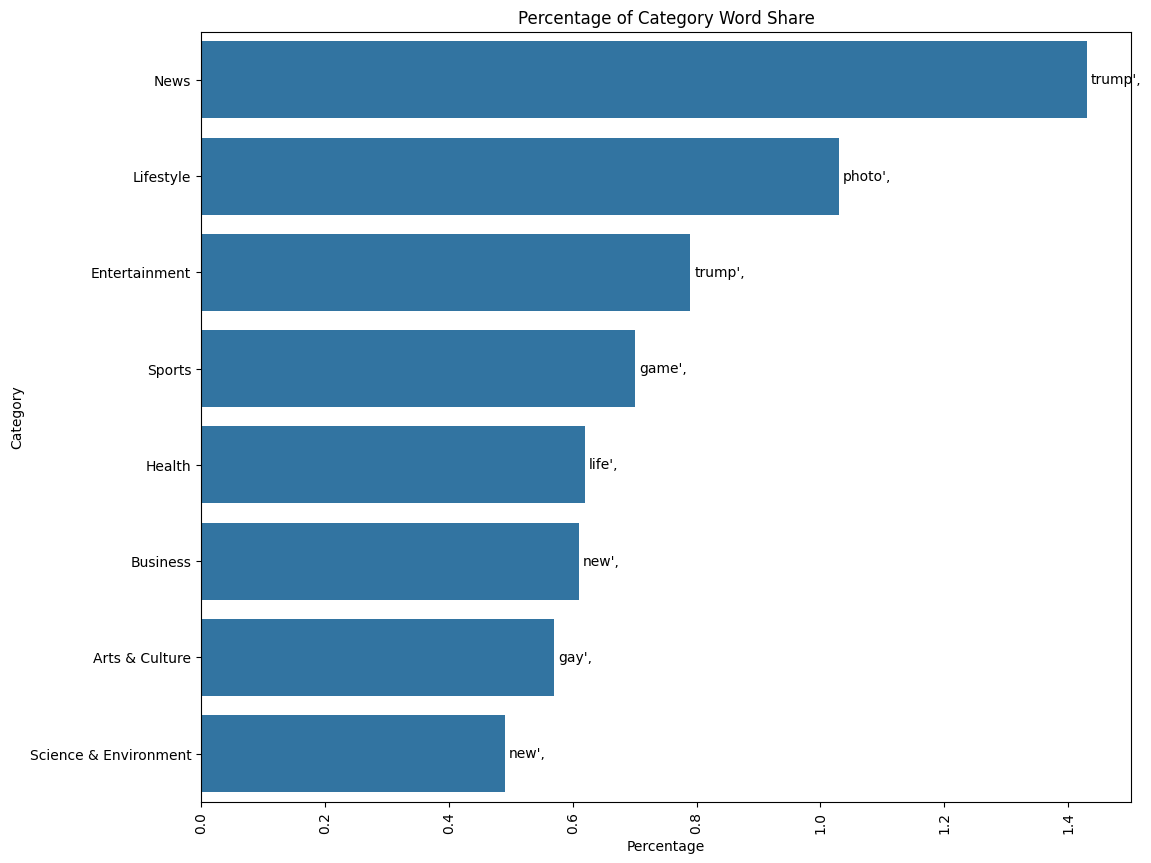

In [32]:
# Plot in bar plot
fig, ax = plt.subplots(figsize=(12,10))
sns.barplot(x='percentage', y='category', data=cat_most_freq)
plt.xlabel('Percentage')
plt.ylabel('Category')
ax.bar_label(ax.containers[0], labels=[word.strip("['']") for word in cat_most_freq.word], padding=3)
plt.xticks(rotation=90)
plt.title('Percentage of Category Word Share')
plt.show()

All words have less than a 2% of total word share in the categories. Trump had the largest count in a category by far, and we can see here it leads in percentage too at 1.4%.

Photo took up a sizable share in our lifestyle category.

# N-grams

We'll examine both bi-grams and tri-grams to analyze the most frequent 2 and 3 word phrases in our set

In [33]:
# Create new df to convert description into string
data_string = data[['category', 'description']]
data_string.head()

,category,description
0,News,"['million', 'american', 'roll', 'sleeve', 'omicrontargeted', 'covid', 'booster', 'health', 'expert', 'said', 'early', 'predict', 'whether', 'demand', 'would', 'match', '171', 'million', 'dos', 'new', 'booster', 'ordered', 'fall']"
1,News,"['american', 'airline', 'flyer', 'charged', 'banned', 'life', 'punching', 'flight', 'attendant', 'video', 'subdued', 'passenger', 'crew', 'fled', 'back', 'aircraft', 'confrontation', 'according', 'attorney', 'office', 'los', 'angeles']"
2,Entertainment,"['funniest', 'tweet', 'cat', 'dog', 'week', 'sept', '1723', 'dog', 'dont', 'understand', 'could', 'eaten']"
3,Lifestyle,"['funniest', 'tweet', 'parent', 'week', 'sept', '1723', 'accidentally', 'put', 'grownup', 'toothpaste', 'toddler', 'toothbrush', 'screamed', 'like', 'cleaning', 'teeth', 'carolina', 'reaper', 'dipped', 'tabasco', 'sauce']"
4,News,"['woman', 'called', 'cop', 'black', 'birdwatcher', 'loses', 'lawsuit', 'exemployer', 'amy', 'cooper', 'accused', 'investment', 'firm', 'franklin', 'templeton', 'unfairly', 'firing', 'branding', 'racist', 'video', 'central', 'park', 'encounter', 'went', 'viral']"


In [34]:
# Convert back into continuous sentence format
data_string.loc[:, 'description'] = data_string['description'].apply(lambda x: " ".join(x.strip("['']").replace("', '", " ").split()))
data_string.head()

,category,description
0,News,million american roll sleeve omicrontargeted covid booster health expert said early predict whether demand would match 171 million dos new booster ordered fall
1,News,american airline flyer charged banned life punching flight attendant video subdued passenger crew fled back aircraft confrontation according attorney office los angeles
2,Entertainment,funniest tweet cat dog week sept 1723 dog dont understand could eaten
3,Lifestyle,funniest tweet parent week sept 1723 accidentally put grownup toothpaste toddler toothbrush screamed like cleaning teeth carolina reaper dipped tabasco sauce
4,News,woman called cop black birdwatcher loses lawsuit exemployer amy cooper accused investment firm franklin templeton unfairly firing branding racist video central park encounter went viral


Now that we have the data back into a continuous format, we can analyze bi-grams and tri-grams. We'll start with bi-grams

In [35]:
# Import/download packages
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1002)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1002)>


False

In [37]:
# Generate and count bigrams from description
tokens = data_string['description'].str.cat(sep=' ').split()

# Create bigrams
from nltk.util import bigrams
nltk_bigrams = list(bigrams(tokens))

# Count the bigrams
from collections import Counter
bigram_counts = Counter(nltk_bigrams)

# Convert to Series for easier viewing
bigrams_series = pd.Series(bigram_counts).sort_values(ascending=False)
bigrams_series.head()

Tears    eye        11577
donald   trump       6603
new      york        3139
hillary  clinton     1914
white    house       1700
dtype: int64

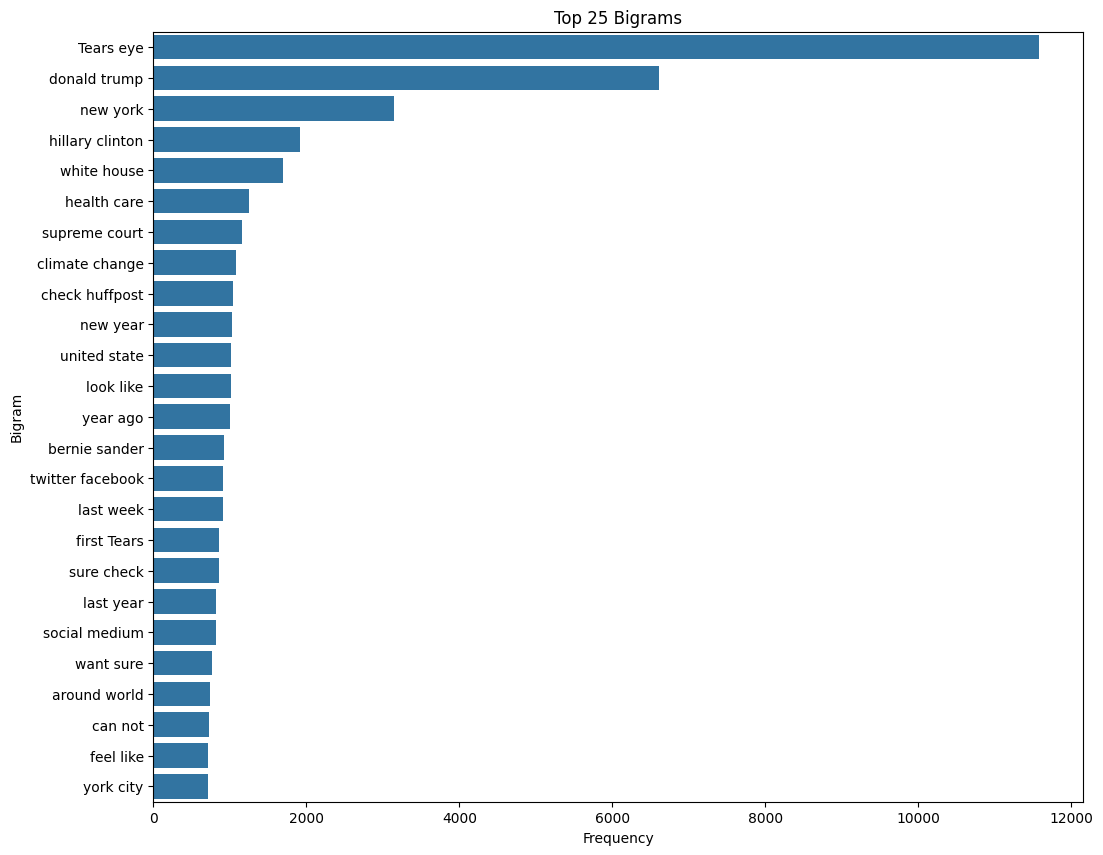

In [38]:
# Separate into top 25 bigrams and plot
top_25_bigrams = bigrams_series[:25]

# Convert the bigram tuples to strings for plotting
bigram_labels = [' '.join(bigram) for bigram in top_25_bigrams.index]

plt.figure(figsize=(12,10))
sns.barplot(x=top_25_bigrams.values, y=bigram_labels)
plt.ylabel('Bigram')
plt.xlabel('Frequency')
plt.title('Top 25 Bigrams')
plt.show()

We can see that tear eye is the most common bigram by a wide margin. This is interesting it exceeded other bigrams by so much. Most of the other top results are significant political people (Trump, Hillary Clinton, Bernie Sanders) or locations.

Now we'll do the same for trigrams

In [39]:
# Create trigrams
from nltk.util import trigrams
nltk_trigrams = list(trigrams(tokens))

# Count the bigrams
trigram_counts = Counter(nltk_trigrams)

# Convert to Series for easier viewing
trigrams_series = pd.Series(trigram_counts).sort_values(ascending=False)
trigrams_series.head()

first     Tears     eye          863
want      sure      check        747
new       york      city         708
twitter   facebook  tumblr       677
facebook  tumblr    pinterest    642
dtype: int64

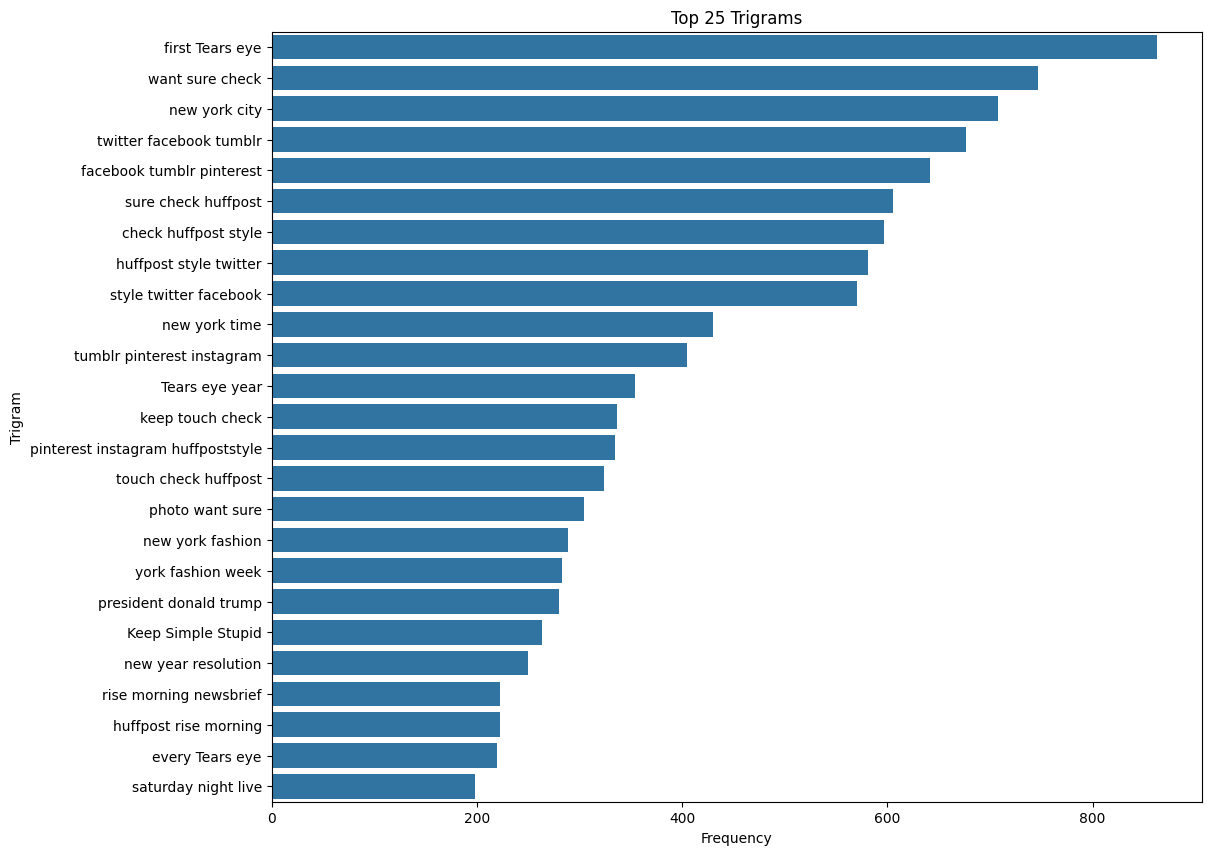

In [40]:
# Separate into top 25 trigrams and plot
top_25_trigrams = trigrams_series[:25]

# Convert the trigram tuples to strings for plotting
trigram_labels = [' '.join(trigram) for trigram in top_25_trigrams.index]

plt.figure(figsize=(12,10))
sns.barplot(x=top_25_trigrams.values, y=trigram_labels)
plt.ylabel('Trigram')
plt.xlabel('Frequency')
plt.title('Top 25 Trigrams')
plt.show()

Here we can see the frequncy for our top results are much more evenly distributed in frequency. First tear eye is the top result followed by want sure check. Our top bigram, tear eye appears in 4 of the top 25 results.

We do see a lot fo trigrams includings social media sites like twitter, facebook, tumbler, pinterest, and instagram. These probably stem from ads within the short descriptions.